In [ ]:
# Create a folder for your project images
!mkdir -p project_images

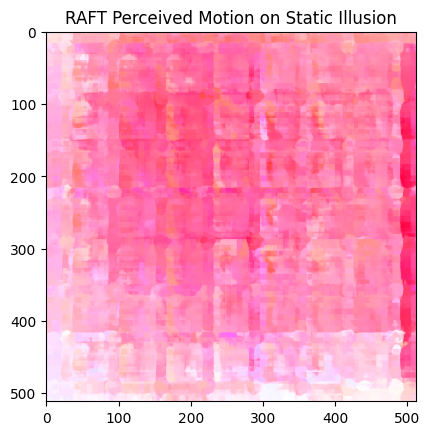

In [ ]:
import torch
import torchvision
from torchvision.models.optical_flow import raft_large
from torchvision.utils import flow_to_image
from torchvision.io import read_image
import matplotlib.pyplot as plt

# Load Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = raft_large(weights="Raft_Large_Weights.DEFAULT", progress=False).to(device).eval()

# RAFT needs two 'frames'. For a static illusion, we use the same image twice.
# If the model 'sees' motion, the resulting flow will not be zero.
img = read_image("project_images/grid.jpg")[:3, :, :].unsqueeze(0).to(device).float()
img = torchvision.transforms.functional.resize(img, [512, 512]) # Resize to multiple of 8

with torch.no_grad():
    flow = model(img, img)[-1]

# Save and Display
flow_img = flow_to_image(flow[0]).cpu().permute(1, 2, 0).numpy()
plt.imshow(flow_img)
plt.title("RAFT Perceived Motion on Static Illusion")
plt.savefig("raft_illusion_result.png")